**Name:  Anjali Arvind Shirke**    
**Roll No : 07**    
**Assignment 10**   

### Aim
Write Python program to implement CNN object detection. Discuss numerous performance evaluation metrics for evaluating the object-detecting algorithms' performance.

In [41]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

In [43]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print(f'Train : {x_train.shape}   Test : {x_test.shape}')
print(f'Image shape : {x_train[0].shape}   Pixel range : [0, 255]')

Train : (50000, 32, 32, 3)   Test : (10000, 32, 32, 3)
Image shape : (32, 32, 3)   Pixel range : [0, 255]


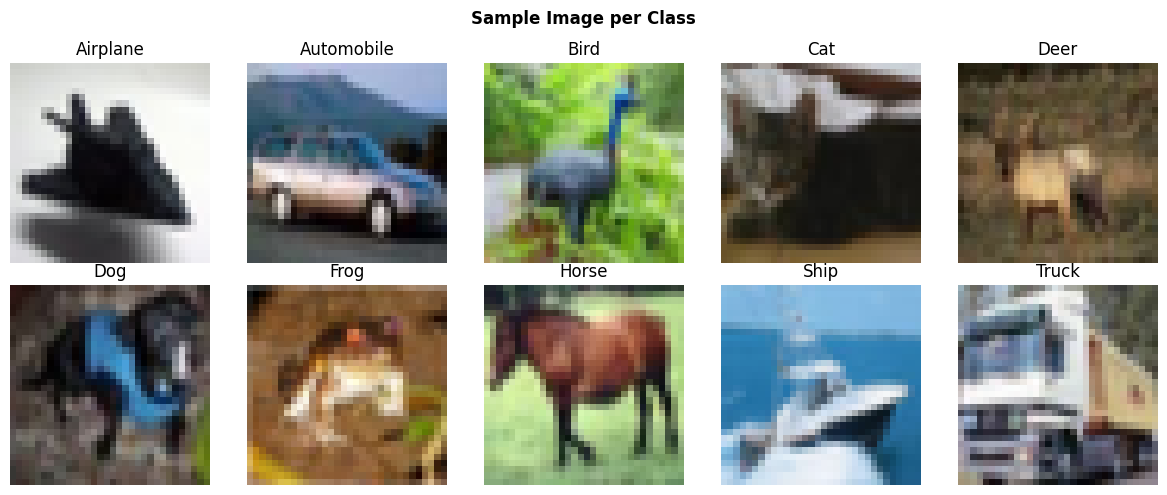

In [44]:
# Sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    axes[i//5, i%5].imshow(x_train[idx])
    axes[i//5, i%5].set_title(class_names[i])
    axes[i//5, i%5].axis('off')
plt.suptitle('Sample Image per Class', fontweight='bold')
plt.tight_layout(); plt.show()

In [45]:
# Class distribution
_, counts = np.unique(y_train, return_counts=True)
print(f'Classes : {len(class_names)} - {counts[0]} images each (balanced)')

Classes : 10 - 5000 images each (balanced)


In [54]:
# Normalization of Data
x_train_n = x_train.astype('float32') / 255.0
x_test_n  = x_test.astype('float32') / 255.0

In [55]:
# Simple CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

C:\Users\anjal\PythonP\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Training the model
history = model.fit(x_train_n, y_train, epochs=5, batch_size=64,
                    validation_split=0.1, verbose=1)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.4476 - loss: 1.5281 - val_accuracy: 0.5500 - val_loss: 1.2779
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5864 - loss: 1.1725 - val_accuracy: 0.6014 - val_loss: 1.1196
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.6362 - loss: 1.0441 - val_accuracy: 0.6492 - val_loss: 1.0068
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.6649 - loss: 0.9600 - val_accuracy: 0.6716 - val_loss: 0.9521
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.6896 - loss: 0.8946 - val_accuracy: 0.6804 - val_loss: 0.9293


In [57]:
# Testing the model
loss, acc = model.evaluate(x_test_n, y_test, verbose=0)
print(f'Test Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')

Test Accuracy : 0.6642
Test Loss     : 0.9571


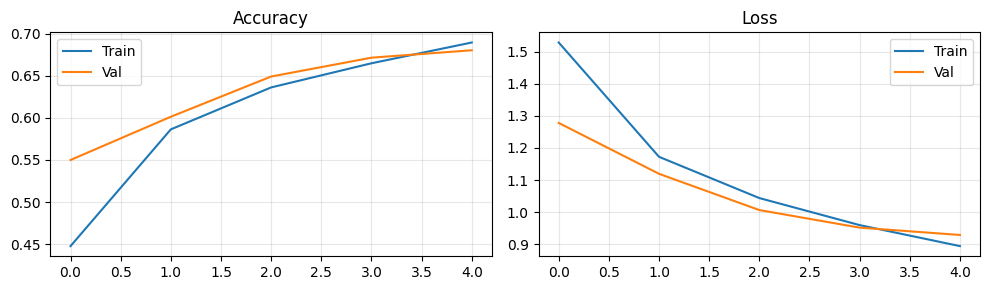

In [58]:
# Training curves
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3))
a1.plot(history.history['accuracy'], label='Train')
a1.plot(history.history['val_accuracy'], label='Val')
a1.set_title('Accuracy'); a1.legend(); a1.grid(alpha=.3)
a2.plot(history.history['loss'], label='Train')
a2.plot(history.history['val_loss'], label='Val')
a2.set_title('Loss'); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [59]:
y_pred = np.argmax(model.predict(x_test_n, verbose=0), axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.70      0.71      0.71      1000
  Automobile       0.81      0.77      0.79      1000
        Bird       0.52      0.58      0.55      1000
         Cat       0.50      0.48      0.49      1000
        Deer       0.57      0.64      0.60      1000
         Dog       0.56      0.60      0.58      1000
        Frog       0.78      0.73      0.75      1000
       Horse       0.80      0.67      0.73      1000
        Ship       0.66      0.84      0.74      1000
       Truck       0.84      0.63      0.72      1000

    accuracy                           0.66     10000
   macro avg       0.68      0.66      0.67     10000
weighted avg       0.68      0.66      0.67     10000



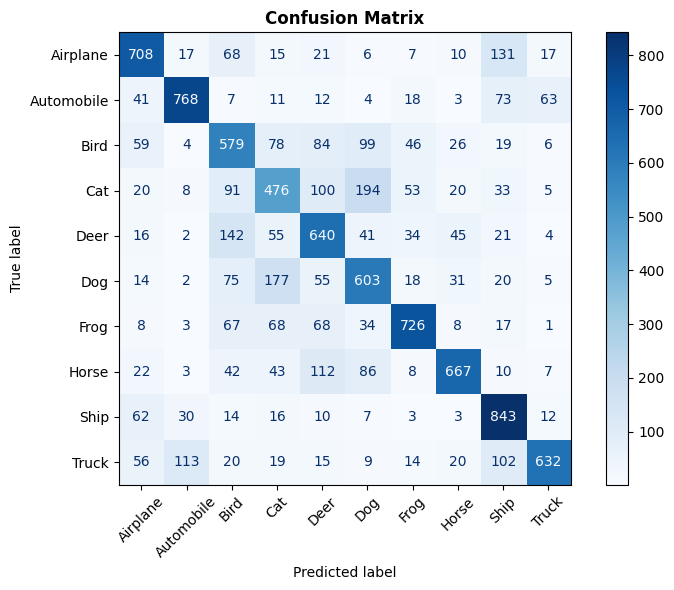

In [60]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

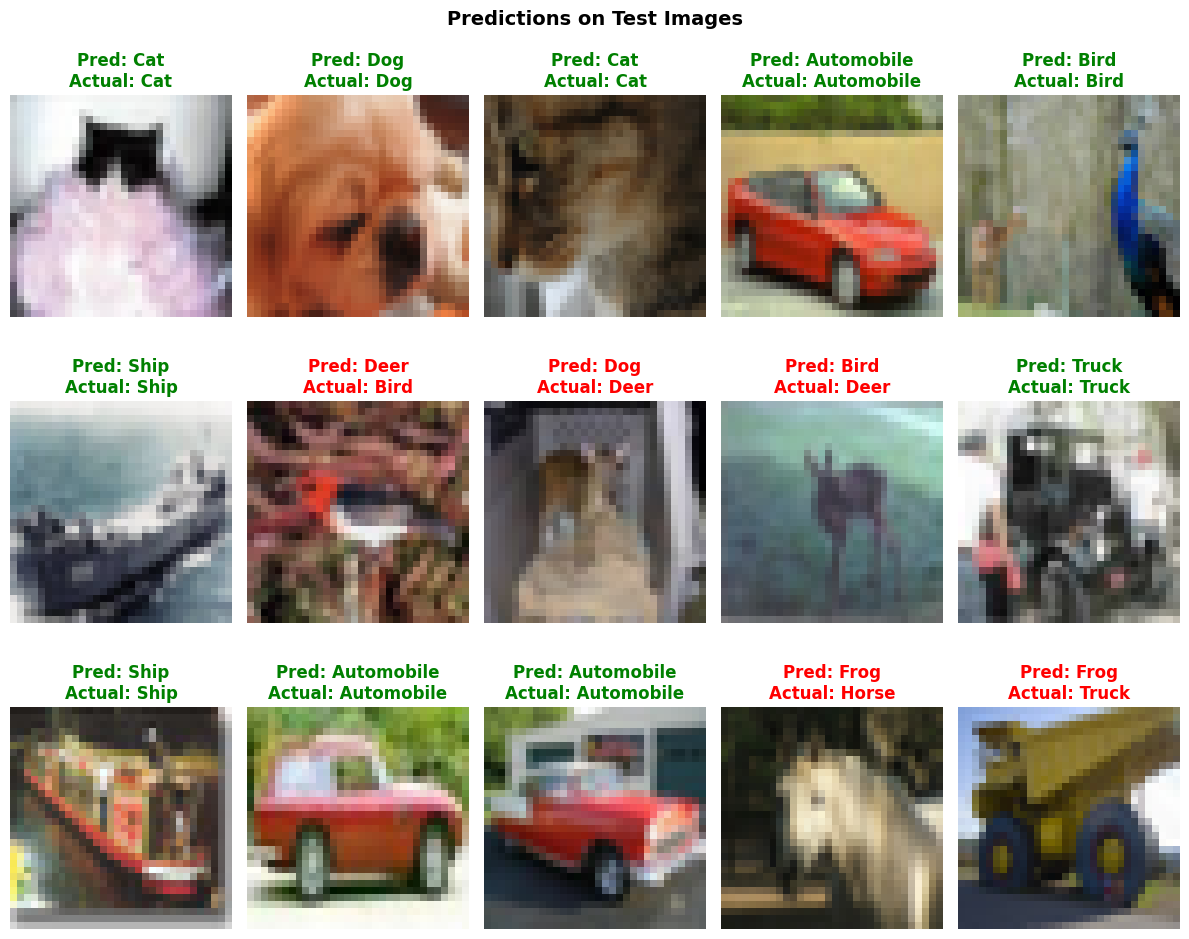

In [61]:
fig, axes = plt.subplots(3, 5, figsize=(12, 10))
for i in range(15):
    idx = np.random.randint(0, len(x_test_n))
    ax = axes[i//5, i%5]
    ax.imshow(x_test_n[idx])
    predicted_class = class_names[y_pred[idx]]
    actual_class = class_names[y_true[idx]]
    color = 'green' if y_pred[idx] == y_true[idx] else 'red'
    ax.set_title(f'Pred: {predicted_class}\nActual: {actual_class}', color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [62]:
def compute_iou(b1, b2):
    """IoU between two [x1, y1, x2, y2] boxes."""
    xi1, yi1 = max(b1[0],b2[0]), max(b1[1],b2[1])
    xi2, yi2 = min(b1[2],b2[2]), min(b1[3],b2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    union = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
    return inter / union if union > 0 else 0

gt_box   = [50, 50, 200, 200]
pred_box = [60, 55, 210, 195]
iou = compute_iou(gt_box, pred_box)

print(f'Ground Truth : {gt_box}')
print(f'Prediction   : {pred_box}')
print(f'IoU          : {iou:.4f}')

Ground Truth : [50, 50, 200, 200]
Prediction   : [60, 55, 210, 195]
IoU          : 0.8201


In [63]:
single = x_test_n[0:1]
_ = model.predict(single, verbose=0)  # warm-up

t0 = time.time()
for _ in range(20):
    model.predict(single, verbose=0)
avg = (time.time() - t0) / 20

print(f'Average latency : {avg*1000:.2f} ms')
print(f'Approximate FPS : {1/avg:.2f}')

Average latency : 126.01 ms
Approximate FPS : 7.94
